In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision import transforms
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
class ConvStem(nn.Module):
    """Small CNN that downsamples to a feature grid."""
    def __init__(self, img_size=32, embed_dim=256, num_stages=3):
        super().__init__()
        layers = []
        in_ch = 3
        chs = [embed_dim // 4, embed_dim // 2, embed_dim]  # for 3 stages
        for i, out_ch in enumerate(chs):
            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1))
            if i < num_stages - 1:
                layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.GELU())
            in_ch = out_ch
        self.stem = nn.Sequential(*layers)
        self.grid_size = img_size // (2 ** num_stages)  # e.g., 4 for 32x32

    def forward(self, x):
        return self.stem(x)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv_proj = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.size()
        qkv = self.qkv_proj(x).view(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)
        context = (attn @ v).transpose(1, 2).contiguous().view(B, N, D)
        return self.proj_drop(self.out_proj(context))

class FeedForward(nn.Module):  # SwiGLU
    def __init__(self, embed_dim, expansion=4, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * expansion * 2 / 3)
        self.w_gate = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.w_value = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.w_out = nn.Linear(hidden_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gate = torch.sigmoid(self.w_gate(x)) * self.w_gate(x)  # Swish
        value = self.w_value(x)
        x = gate * value
        return self.dropout(self.w_out(x))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, expansion=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.mlp = FeedForward(embed_dim, expansion, dropout)
        self.ls1 = nn.Parameter(torch.full((embed_dim,), 1e-4))
        self.ls2 = nn.Parameter(torch.full((embed_dim,), 1e-4))

    def forward(self, x):
        x = x + self.ls1 * self.attn(self.norm1(x))
        x = x + self.ls2 * self.mlp(self.norm2(x))
        return x

class MIMDecoder(nn.Module):
    """Lightweight decoder for masked feature reconstruction."""
    def __init__(self, embed_dim, num_patches, num_layers=2, num_heads=4):
        super().__init__()
        self.num_patches = num_patches
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, dropout=0.0) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.pred = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, ids_keep):
        # x: visible encoder patch tokens (B, len_keep, C)
        # ids_keep: indices of these tokens in the original grid (from ids_shuffle[:, :len_keep])
        B, N_vis, C = x.shape
        total_patches = self.num_patches
    
        # Full sequence of mask tokens
        mask_tokens = self.mask_token.expand(B, total_patches, -1)
    
        # Place the visible tokens at their original positions
        full_x = mask_tokens.clone()
        full_x.scatter_(1, ids_keep.unsqueeze(-1).expand(-1, -1, C), x)
    
        # Add decoder positional embeddings
        full_x = full_x + self.decoder_pos_embed
    
        for blk in self.blocks:
            full_x = blk(full_x)
        full_x = self.norm(full_x)
        return self.pred(full_x)

class MIMSmallViT(nn.Module):
    def __init__(self, img_size=32, embed_dim=256, num_heads=4, num_blocks=4,
                 num_reg_tokens=4, conv_stages=3, mask_ratio=0.6, decoder_layers=2):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.num_reg_tokens = num_reg_tokens
        self.stem = ConvStem(img_size, embed_dim, num_stages=conv_stages)
        self.grid_size = self.stem.grid_size
        num_patches = self.grid_size ** 2
        self.num_patches = num_patches

        # Encoder's position embedding (registers + all patches)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + num_reg_tokens, embed_dim))
        self.reg_tokens = nn.Parameter(torch.randn(1, num_reg_tokens, embed_dim))
        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, dropout=0.0) for _ in range(num_blocks)
        ])
        self.decoder = MIMDecoder(embed_dim, num_patches, decoder_layers, num_heads)
        # No PEG during MIM

    def forward(self, x):
        B = x.size(0)
        # 1. Stem -> feature grid
        features = self.stem(x)                                 # (B, C, H, W)
        H, W = self.grid_size, self.grid_size
        features_flat = features.flatten(2).transpose(1, 2)     # (B, N, C)
        N = self.num_patches
        target = features_flat.detach()                         # save full stem features as target
        mean = target.mean(dim=(0,1), keepdim=True)   # per-channel mean
        std = target.std(dim=(0,1), keepdim=True) + 1e-6
        target = (target - mean) / std
    
        # 2. Masking
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
    
        # 3. Select visible features
        x_vis = torch.gather(features_flat, dim=1,
                             index=ids_keep.unsqueeze(-1).expand(-1, -1, features_flat.size(-1)))

        # 4. Attach registers + positional embeddings
        reg = self.reg_tokens.expand(B, -1, -1)
        pos_reg = self.pos_embed[:, :self.num_reg_tokens, :]
        pos_patches = self.pos_embed[:, self.num_reg_tokens:, :]  # (1, N, C)
        pos_vis = pos_patches.expand(B, -1, -1).gather(1, ids_keep.unsqueeze(-1).expand(-1, -1, pos_patches.size(-1)))
        x_vis = torch.cat([reg, x_vis], dim=1)
        x_vis = x_vis + torch.cat([pos_reg.expand(B, -1, -1), pos_vis], dim=1)
    
        # 5. Encoder
        for blk in self.blocks:
            x_vis = blk(x_vis)
    
        # 6. Remove registers for decoder
        x_enc_patches = x_vis[:, self.num_reg_tokens:, :]   # (B, len_keep, C)
    
        # 7. Decoder predicts all stem features
        pred = self.decoder(x_enc_patches, ids_keep)        # (B, N, C)
    
        # 8. Loss on masked positions only
        mask = torch.ones(B, N, dtype=torch.bool, device=x.device)  # start with all True
        mask.scatter_(1, ids_keep, False)                            # set visible to False
        loss = F.mse_loss(pred[mask], target[mask])
        return loss

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = "cpu"
print(f"Using device: {device}")

model = MIMSmallViT(
    img_size=32, embed_dim=256, num_heads=4, num_blocks=8,
    num_reg_tokens=4, conv_stages=3, mask_ratio=0.75, decoder_layers=2
).to(device)

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Using device: cuda
8.33M


In [4]:
def get_cifar10_subset():
    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),  # strong spatial augmentation
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(num_ops=2, magnitude=9),       # heavy color/geometric jitter
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])

    full_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    # Select 100 images per class
    targets = np.array(full_dataset.targets)
    indices = []
    for c in range(10):
        c_idx = np.where(targets == c)[0]
        indices.extend(np.random.choice(c_idx, 100, replace=False))
    subset = Subset(full_dataset, indices)
    return subset

dataset = get_cifar10_subset()
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
print(len(dataset))

1000


In [5]:
num_epochs = 200 
optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
losses = []

for epoch in range(1, num_epochs+1):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch}/{num_epochs}')
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model(imgs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch}: average loss = {avg_loss:.6f}")

    # Save checkpoint periodically
    if epoch % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, f'mim_checkpoint_epoch{epoch}.pth')

# Save final model
torch.save(model.state_dict(), 'mim_smallvit_final.pth')

Epoch 1/200: 100%|██████████| 16/16 [00:01<00:00, 10.19it/s, loss=1.22]


Epoch 1: average loss = 1.266424


Epoch 2/200: 100%|██████████| 16/16 [00:00<00:00, 21.61it/s, loss=1.08]


Epoch 2: average loss = 1.149458


Epoch 3/200: 100%|██████████| 16/16 [00:00<00:00, 18.50it/s, loss=1.04]


...

Epoch 198: average loss = 0.426194


Epoch 199/200: 100%|██████████| 16/16 [00:00<00:00, 21.46it/s, loss=0.406]


Epoch 199: average loss = 0.407423


Epoch 200/200: 100%|██████████| 16/16 [00:00<00:00, 21.70it/s, loss=0.347]


Epoch 200: average loss = 0.405329


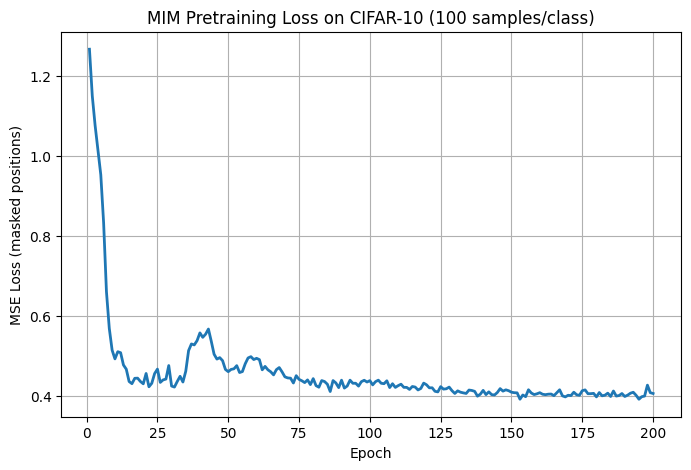

In [8]:
# Plot loss
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (masked positions)')
plt.title('MIM Pretraining Loss on CIFAR-10 (100 samples/class)')
plt.grid(True)
plt.savefig('mim_loss_plot.png')
plt.show()